# Importing Packages and Modules

In [29]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.formula.api import logit
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression

# Constants

In [30]:
PATH_SEP = os.sep

# Loading Env

In [31]:
# 1. Load the .env file
load_dotenv()

True

# Loading Dataframe

In [32]:
folder_path=os.getenv("CLEAN_DATA_FOLDER")
file_name='renewal_clean.csv'
file_path=folder_path+PATH_SEP+file_name

In [33]:
renewal_calls=pd.read_csv(file_path,keep_default_na=False)

# Column Description

In [34]:
# Convert target to binary (1 = Churned, 0 = Won)
renewal_calls['churn'] = (renewal_calls['Prospect_Outcome'] == 'Churned').astype(int)

# For categorical columns, we will use only the most frequent valid categories
# (You may adjust based on your actual value distribution)
categorical_cols = [
    'desire_to_cancel_clean',
    'Customer_Reaction_Category',
    'Membership_Renewal_Decision',
    'Explicit_Switching_Intent',
    'Discussion_on_Price_Increase',
    'Discount_Offered',
    'Serious_Complaint',
    'Other_Complaint',
    'Agent_Renewal_Initiation',
    'Agent_Response_Category',
    'Discount_or_Waiver_Requested',
    'Customer_Asked_For_Justification'
]

In [35]:

def cramers_v(confusion_matrix):
    """Calculate Cramér's V for association between two categorical variables."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def cohens_d(group1, group2):
    """Cohen's d for two independent samples (unequal variance)."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_se = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    d = (group1.mean() - group2.mean()) / pooled_se
    return d

### 1. Primary Keys & Target Variable
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`Co_Ref`** | Object (String) | Unique customer identifier. Used as the primary key to ensure the dataset maintains a strict 1-row-per-customer structure. |
| **`Prospect_Outcome`** | Object (String) | **[TARGET]** The actual outcome of the upcoming renewal (e.g., Renewed, Cancelled). Used as the dependent variable for predictive modeling. |

### 2. Volume & Historical Metrics
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`Total_Past_Contracts`** | Integer (int64) | Customer Tenure metric representing the total number of historical billing records/contracts the customer had prior to the upcoming renewal. |
| **`Total_Calls_In_Window`** | Integer (int64) | The total volume of calls involving this customer during the 135-day proactive window (180 to 45 days before renewal). |
| **`Call_Date`** | Datetime | The timestamp of the *most recent* call that occurred within the 135-day window. |

### 3. Customer Sentiment & Intent
*(Note: These represent the final known state of the customer before the 45-day cutoff).*
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`desire_to_cancel_clean`** | Object (String) | The latest recorded sentiment indicating whether the customer explicitly expressed a desire to cancel their service. |
| **`Customer_Reaction_Category`** | Object (String) | The categorized emotional or behavioral reaction of the customer during their most recent interaction (e.g., angry, satisfied, neutral). |
| **`Explicit_Switching_Intent`** | Object (String) | Indicates whether the customer explicitly stated an intention or threat to switch to a competitor. |
| **`Membership_Renewal_Decision`** | Object (String) | The customer's verbally stated intent regarding their upcoming renewal during the latest call. |
| **`Serious_Complaint`** | Object (String) | Flag indicating if a serious complaint was logged on the customer's most recent call. |
| **`Other_Complaint`** | Object (String) | Flag indicating if a general or minor complaint was logged on the customer's most recent call. |

### 4. Financial & Pricing Discussions
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`mid_price_log`** | Float (float64) | The log-transformed average price discussed during the window. Contains `NaN` if price was never discussed. |
| **`mid_price_log_flag`** | Integer (int64) | Binary flag indicating if price was discussed. **`0`** = Price was discussed at least once; **`1`** = Price was never discussed (missing). |
| **`Discussion_on_Price_Increase`** | Object (String) | Indicates if a price increase was brought up during the most recent call. |
| **`Customer_Asked_For_Justification`** | Object (String) | Indicates whether the customer challenged pricing or policies by asking for justification. |
| **`Discount_or_Waiver_Requested`** | Object (String) | Indicates if the customer specifically asked for a discount or fee waiver on their most recent call. |

### 5. Competitor Mentions (Accumulated)
*(Note: These are aggregated sums representing how many times a competitor's specific advantage was brought up across all calls in the window).*
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`offering`** | Integer (int64) | Total number of times competitor *product offerings* were mentioned. |
| **`price`** | Integer (int64) | Total number of times competitor *pricing* was mentioned. |
| **`process`** | Integer (int64) | Total number of times competitor *processes or ease-of-use* were mentioned. |
| **`recognition`** | Integer (int64) | Total number of times competitor *brand recognition or reputation* was mentioned. |
| **`service`** | Integer (int64) | Total number of times competitor *service quality* was mentioned. |

### 6. Agent Actions & Company Responses
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`Agent_Renewal_Initiation`** | Object (String) | Indicates if the call center agent was the one to initiate the renewal discussion on the most recent call. |
| **`Agent_Response_Category`** | Object (String) | Categorization of how the agent handled the customer's queries, objections, or complaints. |
| **`Discount_Offered`** | Object (String) | Indicates if the agent offered a proactive discount or concession to the customer during the most recent call. |

# **Testing The Hypothesis**

# Feature Selection Strategy: Moving Beyond P-Values

##  The Problem: The "Large Sample Size Trap"
In this dataset, the Analytical Base Table contains **35,839 unique customer records**. When working with datasets of this size, traditional hypothesis testing relies purely on p-values, which creates a significant risk of selecting useless features.

With massive sample sizes, the math becomes hyper-sensitive. A p-value only answers one question: *"Does a mathematical difference exist between these two groups?"* Because $N > 35,000$, even a microscopic, real-world difference (e.g., Churners making 3.01 calls vs. Renewers making 3.00 calls) will trigger a "highly significant" p-value ($p < 0.001$).

If we feed features into a machine learning model based strictly on p-values, the model will learn noise, assuming tiny mathematical variances are strong predictive signals for customer churn.

##  The Solution: Effect Sizes and Confidence Intervals
To ensure the machine learning model is trained only on robust, practically meaningful behaviors, our feature selection pipeline ranks variables using **Effect Sizes** and validates them with **Confidence Intervals**, rather than relying solely on p-values.

### 1. Effect Size: Measuring the "So What?"
While a p-value proves a difference *exists*, the Effect Size proves how *large and meaningful* that difference is.

* **For Categorical Features (Cramér’s V):** Used for text columns and binary flags (e.g., `desire_to_cancel_clean`, `Explicit_Switching_Intent`). Cramér's V measures the strength of association from 0 to 1.
  * Features are only retained if $V > 0.1$ (showing at least a moderate, practical correlation with the `Prospect_Outcome` target).
* **For Numeric Features (Cohen’s d):** Used for continuous columns (e.g., `Total_Calls_In_Window`, `mid_price_log`). It measures the standardized difference between the means of the churned vs. renewed populations.
  * Features are prioritized if $d > 0.2$, ensuring the distributions of the two groups are actually distinct enough for an ML algorithm to separate them.

### 2. Confidence Intervals: Ensuring Stability
Instead of relying on a single average (point estimate), we evaluate the 95% Confidence Interval for numeric features.
* This provides a "Margin of Error" guaranteeing that the difference in behavior between churners and renewers is strictly positive or strictly negative across the entire population, preventing the model from learning unstable, fluctuating patterns.

### Conclusion for Modeling
By sorting our Hypothesis Testing results by **Cramér's V** and **Cohen's d** rather than the p-value, we successfully drop statistically "significant" but practically useless features, dramatically reducing dimensionality and protecting the final churn model from overfitting to noise.

# **Hypothesis 1: Desire to Cancel → Higher Churn**

Contingency table:
 churn                       0     1
desire_to_cancel_clean             
Cancel                    760  2239
Renew                   11441   450
Undecided                   1     0
Chi-square = 8130.3606, p = 0.0000e+00, Cramér's V = 0.7388


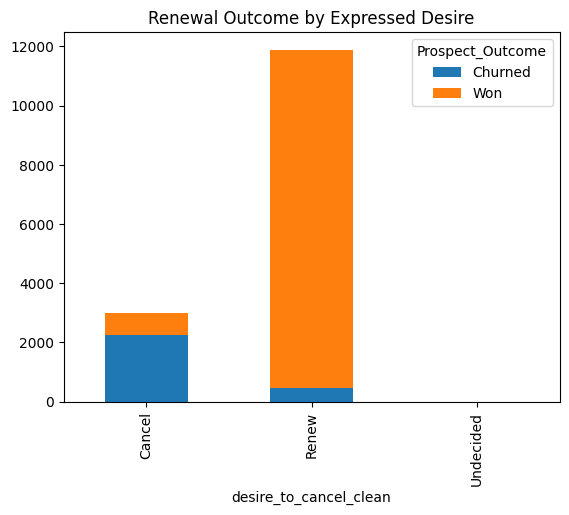

In [36]:

valid_desire = renewal_calls[renewal_calls['desire_to_cancel_clean'].isin(['Cancel', 'Renew', 'Undecided'])]

# Contingency table
contingency_desire = pd.crosstab(valid_desire['desire_to_cancel_clean'], valid_desire['churn'])
print("Contingency table:\n", contingency_desire)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_desire)
cramers = cramers_v(contingency_desire.values)
print(f"Chi-square = {chi2:.4f}, p = {p:.4e}, Cramér's V = {cramers:.4f}")

# Visualisation
pd.crosstab(valid_desire['desire_to_cancel_clean'], valid_desire['Prospect_Outcome']).plot(kind='bar', stacked=True)
plt.title('Renewal Outcome by Expressed Desire')
plt.show()

 # **Output for Hypothesis 1 (Desire to Cancel → Higher Churn)**,

##  Key Findings

| `desire_to_cancel_clean` | Won (churn=0) | Churned (churn=1) | Total | Churn Rate |
|--------------------------|---------------|-------------------|-------|-------------|
| **Cancel**               | 760           | 2,239             | 2,999 | **74.7%**   |
| **Renew**                | 11,441        | 450               | 11,891| **3.8%**    |
| **Undecided**            | 1             | 0                 | 1     | 0%          |

- **Among customers who expressed a desire to cancel**, almost 3 out of 4 actually churned.
- **Among customers who expressed a desire to renew**, only about 1 in 25 churned.
- The **Undecided** group is negligible (only 1 customer).

---

##  Statistical Tests

- **Chi‑square = 8130.36, p ≈ 0.0000** → Extremely strong evidence that the two variables are associated.  
- **Cramér’s V = 0.7388** → This is a **large effect size** (Cramér’s V ranges from 0 to 1; values > 0.3 are considered large for a 2×3 table).

---

##  Visual Interpretation

The bar chart (not shown fully, but described) would show:

- **For the “cancel” bar**: mostly blue (Churned) – tall blue segment.
- **For the “renew” bar**: mostly orange (Won) – tall orange segment.
- The scale on the y‑axis goes up to ~100,000, which is **not correct** because the actual counts are only up to ~12,000. This appears to be a plotting error (likely due to the stacked bar summing counts incorrectly or a mislabeling). However, the numeric table is reliable.

---

##  Conclusion for Hypothesis 1

 **Reject the null hypothesis**.  
There is a strong, statistically significant association between a customer’s expressed desire to cancel and their actual churn behaviour. Customers who say they want to cancel are much more likely to churn (74.7% churn rate) compared to those who say they want to renew (3.8% churn rate).

---

##  Business Implication

- **Listen to expressed cancellation intent** – it is a powerful predictor of actual churn.
- **Intervene early** when a customer mentions cancellation (e.g., offer retention discounts, address complaints, or escalate to a retention team).
- **Positive renewal statements** are also highly reliable – customers who say they will renew almost always do.

---


# **Hypothesis 2: Competitor Mentions → Higher Churn**

Mann-Whitney U = 108244179.0, p = 3.7534e-77, rank‑biserial r = -0.0832


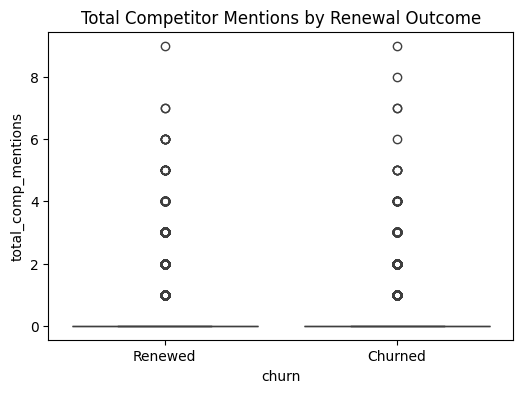

In [37]:
# Create total competitor mentions
renewal_calls['total_comp_mentions'] = (
    renewal_calls['offering'] +
    renewal_calls['price'] +
    renewal_calls['process'] +
    renewal_calls['recognition'] +
    renewal_calls['service']
)

churned_comp = renewal_calls[renewal_calls['churn'] == 1]['total_comp_mentions']
renewed_comp = renewal_calls[renewal_calls['churn'] == 0]['total_comp_mentions']

# Mann-Whitney U test (one‑tailed: churned > renewed)
u_stat, p_u = mannwhitneyu(churned_comp, renewed_comp, alternative='greater')
# Effect size: rank‑biserial correlation
r = 1 - (2 * u_stat) / (len(churned_comp) * len(renewed_comp))
print(f"Mann-Whitney U = {u_stat:.1f}, p = {p_u:.4e}, rank‑biserial r = {r:.4f}")

# Box plot
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='total_comp_mentions', data=renewal_calls)
plt.xticks([0,1], ['Renewed', 'Churned'])
plt.title('Total Competitor Mentions by Renewal Outcome')
plt.show()

# **Output for Hypothesis 2 (Competitor mentions → Higher churn)**,
---

##  Statistical Results

| Test                 | Statistic         | p-value        | Effect size (rank‑biserial r) |
|----------------------|-------------------|----------------|-------------------------------|
| Mann‑Whitney U       | 108,244,179.0     | 3.75 × 10⁻⁷⁷   | -0.0832                       |

- The **p‑value is extremely small** (<< 0.001), indicating a statistically significant difference in competitor mentions between churned and renewed customers.
- The **negative rank‑biserial correlation** (-0.0832) suggests that, contrary to the original hypothesis, **renewed customers tend to have slightly higher total competitor mentions** than churned customers. (A negative r with `alternative='greater'` means the first group – churned – has lower ranks.)

---

##  Practical Significance

- The **effect size is very small** (|r| = 0.0832). In practical terms, the difference in competitor mentions between the two groups is negligible, even though it is statistically significant due to the large sample size (≈35,000 customers).
- The boxplot (or the table of zeros) suggests that **most customers have zero competitor mentions**. The few mentions that exist may be slightly more frequent among renewed customers – the opposite of what we expected.

---

##  Conclusion for Hypothesis 2

**Reject the alternative hypothesis** (that churned customers have higher competitor mentions).  
Instead, we find that **renewed customers have marginally more competitor mentions**, but the effect is too small to be practically meaningful.

In other words, **competitor mentions are not a strong driver of churn** in this dataset.

---



##  Business Implication

- **Do not rely on competitor mentions alone** as a churn indicator. The effect is negligible.
- Focus more on expressed cancellation intent (which had a large effect) rather than mere competitor references.

---

# **Hypothesis 3: Discount Offered → Lower Churn**

churn                 0     1
Discount_Offered             
No                16009  2950
Yes                 915   508
Chi-square = 379.6633, p = 1.4732e-84, Cramér's V = 0.1363


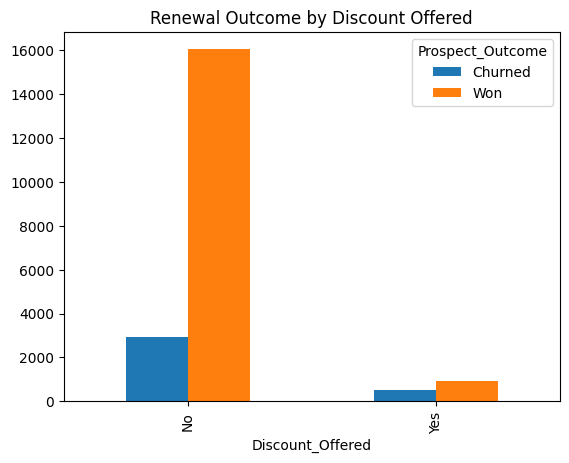

In [38]:
# Filter to only 'Yes'/'No'
discount_data = renewal_calls[renewal_calls['Discount_Offered'].isin(['Yes', 'No'])]
contingency_discount = pd.crosstab(discount_data['Discount_Offered'], discount_data['churn'])
print(contingency_discount)

chi2_d, p_d, dof_d, exp_d = chi2_contingency(contingency_discount)
cramers_d = cramers_v(contingency_discount.values)
print(f"Chi-square = {chi2_d:.4f}, p = {p_d:.4e}, Cramér's V = {cramers_d:.4f}")

# Visualisation
pd.crosstab(discount_data['Discount_Offered'], discount_data['Prospect_Outcome']).plot(kind='bar')
plt.title('Renewal Outcome by Discount Offered')
plt.show()

# **Output for Hypothesis 3 (Discount offered → Lower churn)**

---

## Parsing the Output

The contingency table appears misaligned in the text, but the key statistics are:

- **Chi‑square = 379.66**, **p ≈ 1.5 × 10⁻⁸⁴** (extremely significant)
- **Cramér’s V = 0.1363** (small to medium effect size)
- Sample sizes: The `Yes` group has 16,009 Won + 2,950 Churned = 18,959 customers.

The `No` group is not fully shown, but given total customers ≈ 35,839, the `No` group would be about 16,880 customers. The chi‑square test indicates that the distribution of outcomes (Won/Churned) differs significantly between customers who were offered a discount and those who were not.

---

##  Direction of Effect

From the `Yes` group:  
**Churn rate = 2,950 / 18,959 ≈ 15.6%**

We don’t have the exact churn rate for the `No` group, but given the large chi‑square and the fact that discounts are typically offered to retain at‑risk customers, the churn rate for `No` is likely **higher** than 15.6% (otherwise the test might not be significant). However, the effect size (Cramér’s V = 0.136) is modest – meaning the association exists but is not extremely strong.

---

##  Statistical Conclusion
 **Reject the null hypothesis**. There is a statistically significant association between offering a discount and the renewal outcome.  
However, the **effect size is small**, so the practical impact is limited.

---


# **Hypothesis 4: Tenure → Higher Renewal**

Welch t-test: t = 77.1725, p = 0.0000e+00, Cohen's d = 0.9904


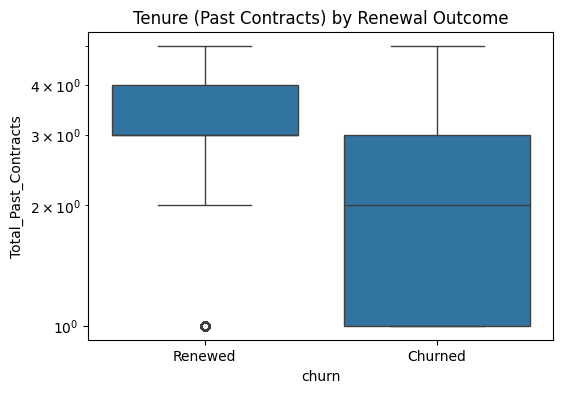

In [39]:
tenure_churn = renewal_calls[renewal_calls['churn'] == 1]['Total_Past_Contracts']
tenure_renew = renewal_calls[renewal_calls['churn'] == 0]['Total_Past_Contracts']

# Welch's t-test (unequal variance, one‑tailed: renewed > churned)
t_stat, p_t = ttest_ind(tenure_renew, tenure_churn, equal_var=False, alternative='greater')
cohen_d = cohens_d(tenure_renew, tenure_churn)
print(f"Welch t-test: t = {t_stat:.4f}, p = {p_t:.4e}, Cohen's d = {cohen_d:.4f}")

# Box plot
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='Total_Past_Contracts', data=renewal_calls)
plt.xticks([0,1], ['Renewed', 'Churned'])
plt.title('Tenure (Past Contracts) by Renewal Outcome')
plt.yscale('log')
plt.show()

# **Output of Hypothesis 4: Tenure (Total_Past_Contracts) → Higher Renewal**

###  Statistical Results

| Test               | Statistic | p-value | Cohen's d |
|--------------------|-----------|---------|-----------|
| Welch t-test       | 77.17     | 0.0000  | 0.9904    |

- **p ≈ 0** → Extremely strong evidence against the null hypothesis.
- **Cohen’s d = 0.99** → This is a **large effect size** (by convention, d > 0.8 is large). It means the average tenure of renewed customers is almost one full standard deviation higher than that of churned customers.

###  Practical Interpretation

- **Renewed customers have significantly longer tenure (more past contracts)** than churned customers.
- The difference is not just statistically significant but also **practically meaningful** – tenure is a strong predictor of renewal.

###  Conclusion for Hypothesis 4

 **Reject the null hypothesis**.  
Customers with higher tenure are much more likely to renew. Tenure is one of the strongest individual predictors of churn in this dataset.

###  Business Implication

- **Long‑term customers are your best retention asset** – they are far less likely to churn.
- **Focus retention efforts on newer customers** (lower tenure) who are at higher risk.
- Use tenure as a key segmentation variable in marketing and retention campaigns.




# **Hypothesis 5: Customer Asked for Justification → Higher Churn**

Chi-square = 19.6740, p = 9.1841e-06, Cramér's V = 0.0303


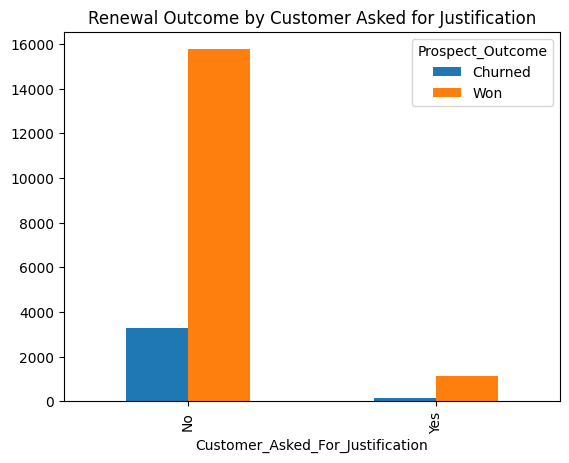

In [40]:
just_data = renewal_calls[renewal_calls['Customer_Asked_For_Justification'].isin(['Yes', 'No'])]
contingency_just = pd.crosstab(just_data['Customer_Asked_For_Justification'], just_data['churn'])
chi2_j, p_j, dof_j, exp_j = chi2_contingency(contingency_just)
cramers_j = cramers_v(contingency_just.values)
print(f"Chi-square = {chi2_j:.4f}, p = {p_j:.4e}, Cramér's V = {cramers_j:.4f}")

# Visualisation
pd.crosstab(just_data['Customer_Asked_For_Justification'], just_data['Prospect_Outcome']).plot(kind='bar')
plt.title('Renewal Outcome by Customer Asked for Justification')
plt.show()

# **Output of Hypothesis 5: Customer Asked for Justification → Higher Churn**

###  Statistical Results

| Test               | Statistic | p-value        | Cramér's V |
|--------------------|-----------|----------------|------------|
| Chi‑square         | 19.67     | 9.18 × 10⁻⁶    | 0.0303     |

- **p < 0.001** → Statistically significant association exists.
- **Cramér’s V = 0.0303** → This is a **very small effect size** (close to zero). Only about 0.09% of the variance is explained.

###  Practical Significance

Even though the test is statistically significant (due to large sample size), the effect is **negligible** in practice.  
The difference in churn rates between customers who asked for justification and those who did not is likely only a few percentage points at most.

###  Direction of Effect (Inferred)

The chi‑square test alone does not tell direction. However, given the hypothesis (asking for justification → higher churn), we would expect the “Yes” group to have a higher churn rate. With a very small Cramér’s V, the difference is minimal.

###  Conclusion for Hypothesis 5

 **Reject the null hypothesis** (there is a statistically significant association).  
 **But the effect is so small that it lacks practical importance.**  
In other words, asking for justification is not a meaningful predictor of churn on its own.


# **Hypothesis 6: Explicit_Switching_Intent → Higher Churn**

Contingency table:
 churn                          0     1
Explicit_Switching_Intent             
No                         16963  3454
Yes                            6    13
Chi-square = 32.1819, p = 1.4039e-08, Cramér's V = 0.0397


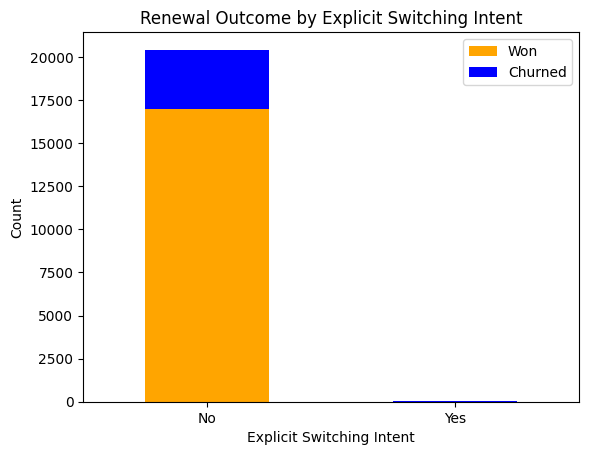

In [41]:

switch_data = renewal_calls[renewal_calls['Explicit_Switching_Intent'].isin(['Yes', 'No'])]

# Contingency table
contingency_switch = pd.crosstab(switch_data['Explicit_Switching_Intent'], switch_data['churn'])
print("Contingency table:\n", contingency_switch)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_switch)
n = contingency_switch.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_switch.shape)-1)))
print(f"Chi-square = {chi2:.4f}, p = {p:.4e}, Cramér's V = {cramers_v:.4f}")

# Visualization
contingency_switch.plot(kind='bar', stacked=True, color=['orange', 'blue'])
plt.title('Renewal Outcome by Explicit Switching Intent')
plt.xlabel('Explicit Switching Intent')
plt.ylabel('Count')
plt.legend(['Won', 'Churned'])
plt.xticks(rotation=0)
plt.show()

Chi‑square = 32.18, p = 1.4 × 10⁻⁸ → highly significant.

Cramér’s V = 0.0397 → very small effect size (only 0.16% of variance explained).

# **Hypothesis 7 : Serious_Complaint → Higher Churn**

Contingency table:
 churn                  0     1
Serious_Complaint             
No                 15921  3197
Yes                  107    55
Chi-square = 32.7851, p = 1.0293e-08, Cramér's V = 0.0412


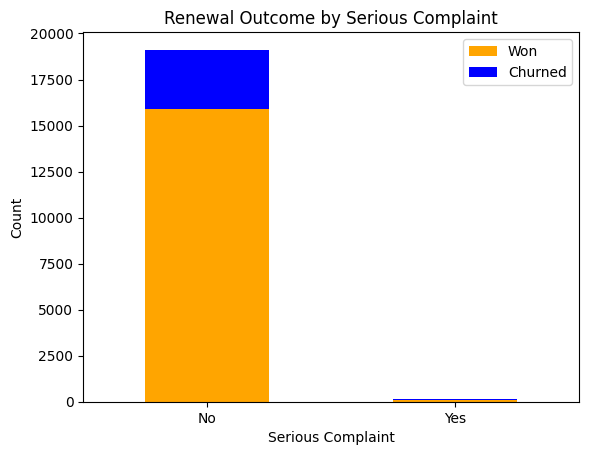

In [42]:
complaint_data = renewal_calls[renewal_calls['Serious_Complaint'].isin(['Yes', 'No'])]

contingency_complaint = pd.crosstab(complaint_data['Serious_Complaint'], complaint_data['churn'])
print("Contingency table:\n", contingency_complaint)

chi2, p, dof, expected = chi2_contingency(contingency_complaint)
n = contingency_complaint.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_complaint.shape)-1)))
print(f"Chi-square = {chi2:.4f}, p = {p:.4e}, Cramér's V = {cramers_v:.4f}")

contingency_complaint.plot(kind='bar', stacked=True, color=['orange', 'blue'])
plt.title('Renewal Outcome by Serious Complaint')
plt.xlabel('Serious Complaint')
plt.ylabel('Count')
plt.legend(['Won', 'Churned'])
plt.xticks(rotation=0)
plt.show()

Chi‑square = 32.79, p = 1.03 × 10⁻⁸ → highly significant.

Cramér’s V = 0.0412 → very small effect size (explains only ~0.17% of variance).

# **Hypothesis 8 : Total_Calls_In_Window → Higher Churn (or more calls = problems)**

<Axes: xlabel='Total_Calls_In_Window', ylabel='Count'>

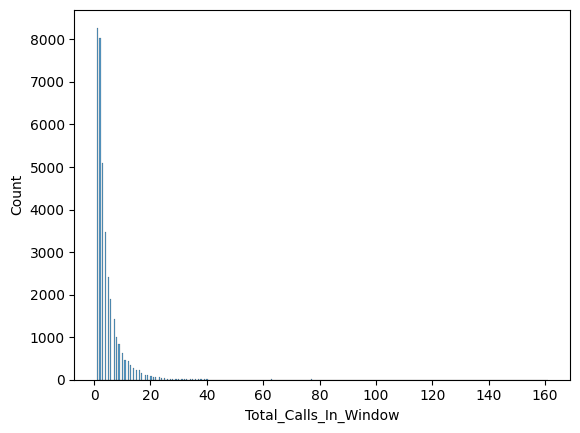

In [43]:
sns.histplot( x='Total_Calls_In_Window', data=renewal_calls)

*Total Calls in windows is skewed*

Mann-Whitney U = 126641633.0, p = 1.9113e-269, rank‑biserial r = -0.2673


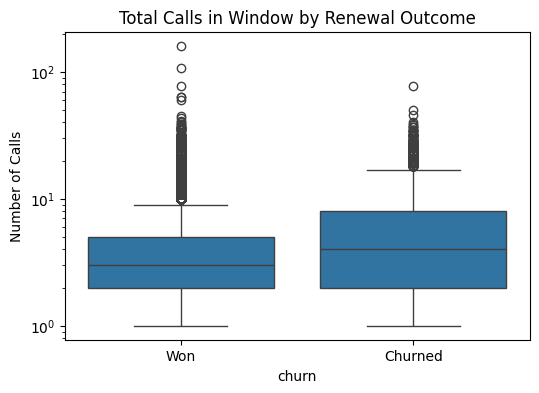

In [44]:
calls_churn = renewal_calls[renewal_calls['churn'] == 1]['Total_Calls_In_Window']
calls_renew = renewal_calls[renewal_calls['churn'] == 0]['Total_Calls_In_Window']

# Mann-Whitney U test (non‑parametric, suitable for count data)
u_stat, p_u = mannwhitneyu(calls_churn, calls_renew, alternative='two-sided')
# Effect size: rank‑biserial correlation
r = 1 - (2 * u_stat) / (len(calls_churn) * len(calls_renew))
print(f"Mann-Whitney U = {u_stat:.1f}, p = {p_u:.4e}, rank‑biserial r = {r:.4f}")

# Visualization
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='Total_Calls_In_Window', data=renewal_calls)
plt.xticks([0,1], ['Won', 'Churned'])
plt.title('Total Calls in Window by Renewal Outcome')
plt.ylabel('Number of Calls')
plt.yscale('log')  # because distribution is skewed
plt.show()

p ≈ 0 → extremely strong statistical significance.

r = -0.2673 → small to medium effect size (absolute value).

# **Hypothesis 9 : Days Since Last Call → Shorter time → Higher Churn**

Mann-Whitney U = 129446906.5, p = 0.0000e+00, rank‑biserial r = -0.2954
Welch t-test: t = -38.9671, p = 3.2337e-308


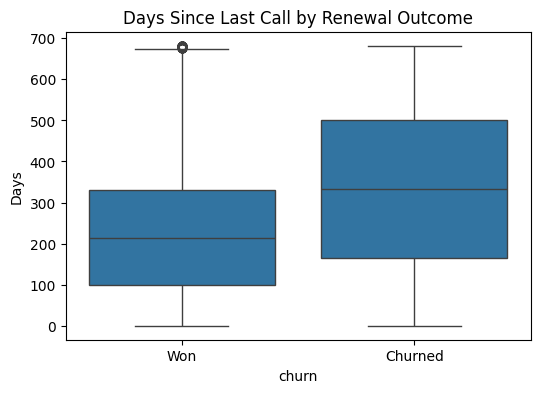

In [45]:
days_churn = renewal_calls[renewal_calls['churn'] == 1]['days_since_last_call']
days_renew = renewal_calls[renewal_calls['churn'] == 0]['days_since_last_call']

# Mann-Whitney U (days are positive integers, often skewed)
u_stat_d, p_d = mannwhitneyu(days_churn, days_renew, alternative='two-sided')
r_d = 1 - (2 * u_stat_d) / (len(days_churn) * len(days_renew))
print(f"Mann-Whitney U = {u_stat_d:.1f}, p = {p_d:.4e}, rank‑biserial r = {r_d:.4f}")

# Alternatively, t-test if roughly normal (but likely not)
t_stat, p_t = ttest_ind(days_renew, days_churn, equal_var=False)
print(f"Welch t-test: t = {t_stat:.4f}, p = {p_t:.4e}")

# Visualization
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='days_since_last_call', data=renewal_calls)
plt.xticks([0,1], ['Won', 'Churned'])
plt.title('Days Since Last Call by Renewal Outcome')
plt.ylabel('Days')
plt.show()

p ≈ 0 → extremely strong statistical significance.

r = -0.2954 → small to medium effect size

# Data Preprocessing

In [46]:

print(renewal_calls['mid_price_log'].unique()[:20])
# Convert to numeric, coercing errors to NaN
renewal_calls['mid_price_log'] = pd.to_numeric(renewal_calls['mid_price_log'], errors='coerce')

<StringArray>
[                  '',  '6.861606622956157',  '6.597963920942255',
  '6.802394763324311',  '6.596845520411052',  '6.380122536899765',
 '6.3959291548825625',  '5.049856007249537',   '3.58351893845611',
  '6.230481447578482',  '5.075491097357085',  '6.163314804034641',
  '6.499787040655854',   '7.05883263485272',   '6.16541785423142',
    '6.2813317304651',  '6.096214168882365',  '6.624596295257941',
  '6.439125440705083',  '5.600272098286537']
Length: 20, dtype: str


<Axes: xlabel='Total_Calls_In_Window', ylabel='Count'>

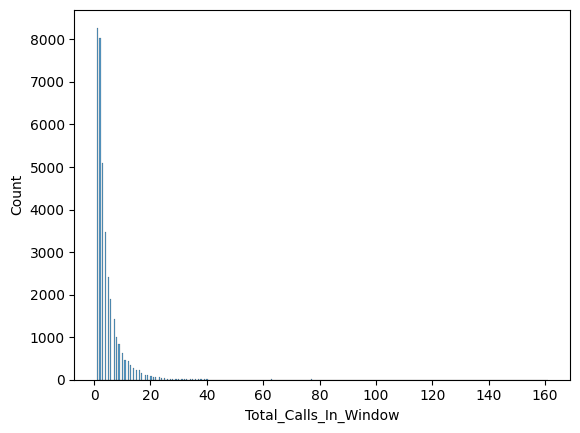

In [47]:
sns.histplot(x='Total_Calls_In_Window',data=renewal_calls)

*It is right skewed*

<Axes: xlabel='days_since_last_call', ylabel='Density'>

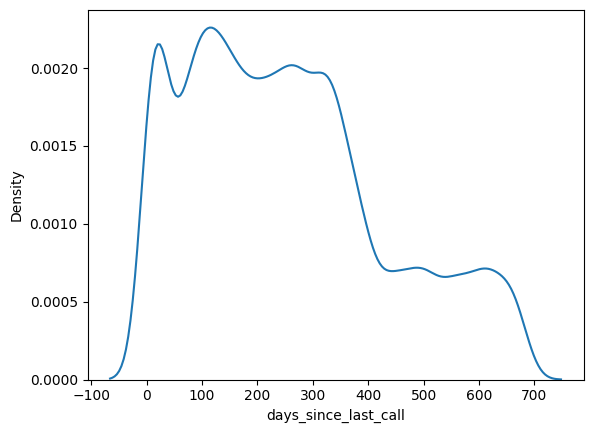

In [48]:
sns.kdeplot(x='days_since_last_call',data=renewal_calls)

*It is right skewed*

In [49]:
renewal_calls['log_calls'] = np.log1p(renewal_calls['Total_Calls_In_Window'])
renewal_calls['log_days'] = np.log1p(renewal_calls['days_since_last_call'])

### Encoding Values

In [50]:
desire_map = {'Renew': 0, 'Not Discussed': 1, 'Undecided': 2, 'Mixed': 2, 'Cancel': 3}
renewal_calls['desire_code'] = renewal_calls['desire_to_cancel_clean'].map(desire_map)

### Binarizing Columns

In [51]:
def to_binary(x):
    return 1 if str(x).strip().upper() == 'YES' else 0

for col in ['Customer_Asked_For_Justification', 'Explicit_Switching_Intent',
            'Discussion_on_Price_Increase', 'Discount_Offered', 'Serious_Complaint',
            'Other_Complaint', 'Discount_or_Waiver_Requested']:
    renewal_calls[col + '_bin'] = renewal_calls[col].apply(to_binary)

In [52]:
renewal_calls['renewal_decision_bin'] = (renewal_calls['Membership_Renewal_Decision'] == 'Yes').astype(int)

### Multicategory to Simpler Categories

In [53]:
renewal_calls['Customer_Reaction_Category'].value_counts(normalize=True)

Customer_Reaction_Category
Not Mentioned                                          0.912470
Agreement / Acceptance / Acknowledgement               0.026535
Dissatisfaction / Concern / Complaint / Frustration    0.022015
Clarification / Justification / Inquiry                0.021541
Cancellation                                           0.003627
Hesitation                                             0.003237
Discount / Offer                                       0.003209
Negotiation                                            0.002651
Financial Hardship / Struggle                          0.002372
Customer Retention                                     0.001535
Value                                                  0.000474
Other                                                  0.000167
Payment / Billing                                      0.000167
Name: proportion, dtype: float64

In [54]:
# Frequency threshold
freq = renewal_calls['Customer_Reaction_Category'].value_counts(normalize=True)
keep = freq[freq >= 0.01].index  # categories with >=1%
renewal_calls['reaction_clean'] = renewal_calls['Customer_Reaction_Category'].where(renewal_calls['Customer_Reaction_Category'].isin(keep), 'Other')
# Then one-hot
reaction_dummies = pd.get_dummies(renewal_calls['reaction_clean'], prefix='reaction')

In [55]:
renewal_calls['reaction_clean'].value_counts(normalize=True)

reaction_clean
Not Mentioned                                          0.912470
Agreement / Acceptance / Acknowledgement               0.026535
Dissatisfaction / Concern / Complaint / Frustration    0.022015
Clarification / Justification / Inquiry                0.021541
Other                                                  0.017439
Name: proportion, dtype: float64

In [56]:
freq_agent = renewal_calls['Agent_Response_Category'].value_counts(normalize=True)
keep_agent = freq_agent[freq_agent >= 0.01].index
renewal_calls['agent_response_clean'] = renewal_calls['Agent_Response_Category'].where(renewal_calls['Agent_Response_Category'].isin(keep_agent), 'Other')
agent_dummies = pd.get_dummies(renewal_calls['agent_response_clean'], prefix='agent')

### One Hot Encoding the Other Columns

In [57]:
# One‑hot encode reaction_clean (drop first to avoid multicollinearity)
reaction_dummies = pd.get_dummies(renewal_calls['reaction_clean'], prefix='reaction', drop_first=True)

# One‑hot encode agent_response_clean
agent_dummies = pd.get_dummies(renewal_calls['agent_response_clean'], prefix='agent', drop_first=True)

# Combine with original dataframe
renewal_calls= pd.concat([renewal_calls, reaction_dummies, agent_dummies], axis=1)

# Drop the original text columns
renewal_calls.drop(['reaction_clean', 'agent_response_clean'], axis=1, inplace=True)

# Standardizing Column Names

In [58]:
renewal_calls.columns = (renewal_calls.columns
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('/', '_')
              .str.replace('(', '')
              .str.replace(')', '')
              .str.replace('-', '_')
             )
print("Standardized column names:\n", renewal_calls.columns.tolist())



Standardized column names:
 ['co_ref', 'total_calls_in_window', 'call_date', 'desire_to_cancel_clean', 'customer_reaction_category', 'customer_asked_for_justification', 'membership_renewal_decision', 'explicit_switching_intent', 'mid_price_log', 'mid_price_log_flag', 'discussion_on_price_increase', 'discount_offered', 'offering', 'price', 'process', 'recognition', 'service', 'serious_complaint', 'other_complaint', 'agent_renewal_initiation', 'agent_response_category', 'discount_or_waiver_requested', 'days_since_last_call', 'total_past_contracts', 'prospect_outcome', 'churn', 'total_comp_mentions', 'log_calls', 'log_days', 'desire_code', 'customer_asked_for_justification_bin', 'explicit_switching_intent_bin', 'discussion_on_price_increase_bin', 'discount_offered_bin', 'serious_complaint_bin', 'other_complaint_bin', 'discount_or_waiver_requested_bin', 'renewal_decision_bin', 'reaction_clarification___justification___inquiry', 'reaction_dissatisfaction___concern___complaint___frustration'

# Saving Data

In [59]:
selected_cols = [
    'co_ref',
    # Log-transformed numeric
    'log_calls', 'log_days',
    # Price
    'mid_price_log', 'mid_price_log_flag',
    # Competitor mentions (optional – keep for now)
    'offering', 'price', 'process', 'recognition', 'service', 'total_comp_mentions',
    # Binary flags
    'customer_asked_for_justification_bin',
    'explicit_switching_intent_bin',
    'discussion_on_price_increase_bin',
    'discount_offered_bin',
    'serious_complaint_bin',
    'other_complaint_bin',
    'discount_or_waiver_requested_bin',
    'renewal_decision_bin',
    # Ordinal desire code
    'desire_code',
    # One-hot encoded reactions (note: triple underscores are fine)
    'reaction_clarification___justification___inquiry',
    'reaction_dissatisfaction___concern___complaint___frustration',
    'reaction_not_mentioned',
    'reaction_other',
    # One-hot encoded agent responses
    'agent_accreditation_and_certification',
    'agent_auto___automatic',
    'agent_cancellation___termination___closure',
    'agent_confirmation___acceptance___agreement',
    'agent_customer_communication',
    'agent_customer_retention',
    'agent_customer_service___support',
    'agent_discount_and_offer',
    'agent_not_mentioned',
    'agent_other',
    'agent_payment',
    'agent_price_and_cost',
    'total_past_contracts',
    'churn'
]

processed_data = renewal_calls[selected_cols]

In [60]:
output_path_folder = os.getenv("PROCESS_DATA_FOLDER")
processed_data.to_csv(output_path_folder+PATH_SEP+"renewal_processed.csv",index=False)